# Analisis exploratorio (EDA)

In [1]:
from scipy import stats
from pathlib import Path
from scipy.stats import shapiro

import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import pyarrow as pa


In [2]:
DATA_DIR = Path.cwd().resolve().parent / 'data'
DATA_DIR

WindowsPath('C:/Users/usuario/Desktop/za-proyecto-I/data')

In [3]:
df_data = pd.read_parquet(DATA_DIR / '01_data_ataques_cardiacos.parquet')

#visualizacion de los datos
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           1319 non-null   int64  
 1   gender        1319 non-null   int64  
 2   heart_rate    1319 non-null   int64  
 3   systolic_bp   1319 non-null   int64  
 4   diastolic_bp  1319 non-null   int64  
 5   blood_sugar   1319 non-null   float64
 6   ckmb          1319 non-null   float64
 7   troponin      1319 non-null   float64
 8   result        1319 non-null   int64  
dtypes: float64(3), int64(6)
memory usage: 92.9 KB


## Conociendo el conjunto datos

### Dimension

In [4]:
print('Dimensiones:',df_data.shape)

Dimensiones: (1319, 9)


### Tipos de datos

In [5]:
print('Tipos de datos:')
df_data.dtypes

Tipos de datos:


age               int64
gender            int64
heart_rate        int64
systolic_bp       int64
diastolic_bp      int64
blood_sugar     float64
ckmb            float64
troponin        float64
result            int64
dtype: object

### Valores nulos

In [6]:
print('\ncantidad de datos nulos:')
df_data.isnull().sum(skipna=False)


cantidad de datos nulos:


age             0
gender          0
heart_rate      0
systolic_bp     0
diastolic_bp    0
blood_sugar     0
ckmb            0
troponin        0
result          0
dtype: int64

### Duplicados

In [7]:
print('cantidad de duplicados:',df_data.duplicated().sum())

cantidad de duplicados: 0


### Estadistica descriptiva

In [8]:
df_data.describe()

,age,gender,heart_rate,systolic_bp,diastolic_bp,blood_sugar,ckmb,troponin,result
count,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000
mean,56.191812,0.659591,78.336619,127.170584,72.269143,146.634344,15.274306,0.360942,0.614102
std,13.647315,0.474027,51.630270,26.122720,14.033924,74.923045,46.327083,1.154568,0.486991
min,14.000000,0.000000,20.000000,42.000000,38.000000,35.000000,0.321000,0.001000,0.000000
25%,47.000000,0.000000,64.000000,110.000000,62.000000,98.000000,1.655000,0.006000,0.000000
50%,58.000000,1.000000,74.000000,124.000000,72.000000,116.000000,2.850000,0.014000,1.000000
75%,65.000000,1.000000,85.000000,143.000000,81.000000,169.500000,5.805000,0.085500,1.000000
max,103.000000,1.000000,1111.000000,223.000000,154.000000,541.000000,300.000000,10.300000,1.000000


## Conversion de datos

In [9]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           1319 non-null   int64  
 1   gender        1319 non-null   int64  
 2   heart_rate    1319 non-null   int64  
 3   systolic_bp   1319 non-null   int64  
 4   diastolic_bp  1319 non-null   int64  
 5   blood_sugar   1319 non-null   float64
 6   ckmb          1319 non-null   float64
 7   troponin      1319 non-null   float64
 8   result        1319 non-null   int64  
dtypes: float64(3), int64(6)
memory usage: 92.9 KB


In [10]:
#variables numericas
cols_numericas = ['heart_rate','systolic_bp','diastolic_bp','blood_sugar','ckmb','troponin']
df_data[cols_numericas] = df_data[cols_numericas].astype('float64')


In [11]:
#variables categoricas
cols_category = ['gender']
df_data[cols_category] = df_data[cols_category].astype('category')

In [12]:
cols_booleanas = ['result']

#cambio de dtype
df_data[cols_booleanas] = df_data[cols_booleanas].astype('bool')

In [13]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   age           1319 non-null   int64   
 1   gender        1319 non-null   category
 2   heart_rate    1319 non-null   float64 
 3   systolic_bp   1319 non-null   float64 
 4   diastolic_bp  1319 non-null   float64 
 5   blood_sugar   1319 non-null   float64 
 6   ckmb          1319 non-null   float64 
 7   troponin      1319 non-null   float64 
 8   result        1319 non-null   bool    
dtypes: bool(1), category(1), float64(6), int64(1)
memory usage: 75.0 KB


## Figuras y graficos

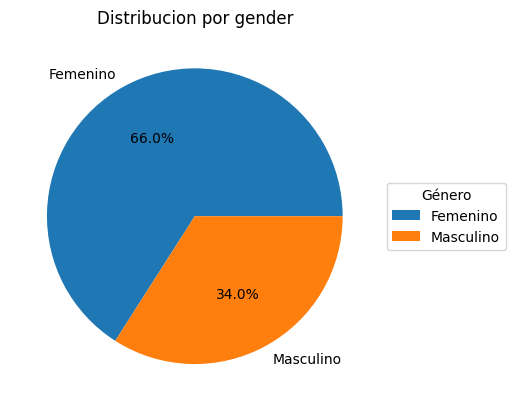

In [14]:
df_data['gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['Femenino', 'Masculino']
    )
plt.legend(labels=['Femenino', 'Masculino'], 
           title="Género", loc="center left", 
           bbox_to_anchor=(1, 0, 0.5, 1)
           )

plt.ylabel('')
plt.title('Distribucion por gender')
plt.show()

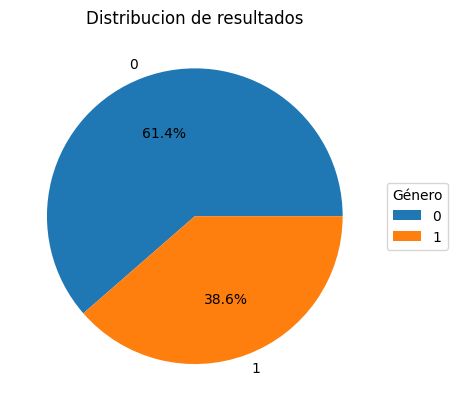

In [15]:
df_data['result'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['0', '1']
    )
plt.legend(labels=['0', '1'], 
           title="Género", loc="center left", 
           bbox_to_anchor=(1, 0, 0.5, 1)
           )

plt.ylabel('')
plt.title('Distribucion de resultados')
plt.show()

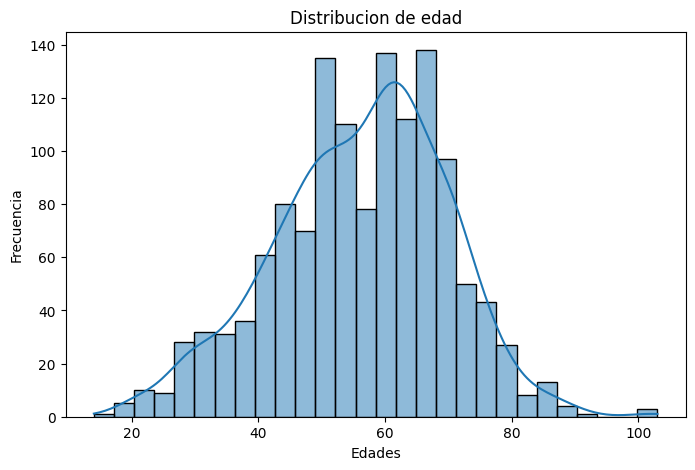

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df_data, x='age', kde=True)

plt.title('Distribucion de edad')
plt.xlabel('Edades')
plt.ylabel('Frecuencia')
plt.show()

Text(0.5, 1.0, 'Boxplot Edad')

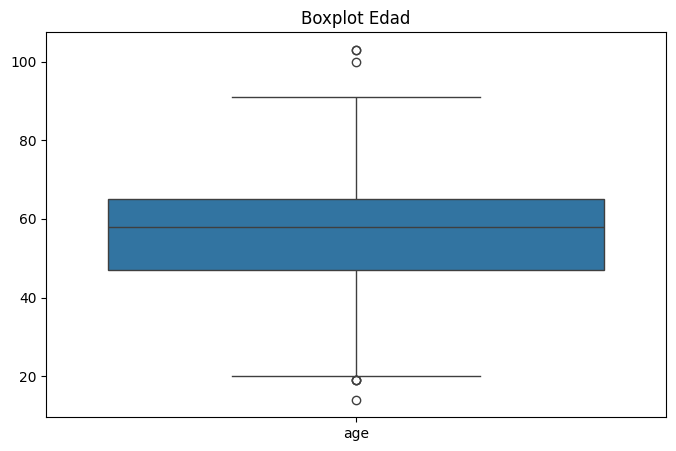

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot([df_data['age']], vert=True)
plt.title('Boxplot Edad')

## Correlacion

In [18]:
# Seleccionamos variables numéricas
var_numericas = df_data[['age','heart_rate','systolic_bp','diastolic_bp','blood_sugar','ckmb','troponin']]
# Prueba de Normalidad
stat, p_age = stats.normaltest(df_data['age'])
stat, p_heart_rate = stats.normaltest(df_data['heart_rate'])
stat, p_systolic_bp = stats.normaltest(df_data['systolic_bp'])
stat, p_diastolic_bp = stats.normaltest(df_data['diastolic_bp'])
stat, p_blood_sugar = stats.normaltest(df_data['blood_sugar'])
stat, p_ckmb = stats.normaltest(df_data['ckmb'])
stat, p_troponin = stats.normaltest(df_data['troponin'])

print("\n--- Justificación de Correlación ---")
print(f"P-valor Edad: {p_age:.5f}")
print(f"P-valor frecuencia cardiaca: {p_heart_rate:.5f}")
print(f"P-valor presion arterial sistolica:{p_systolic_bp:.5f}")
print(f"P-valor presion arterial diastolica: {p_diastolic_bp:.5f}")
print(f"P-valor azucar en sangre: {p_blood_sugar:.5f}")
print(f"P-valor CKMB: {p_ckmb:.5f}")
print(f"P-valor troponina: {p_troponin:.5f}")
# Decisión
metodo = 'pearson' if (p_age > 0.05 and p_heart_rate > 0.05 and p_systolic_bp > 0.05 and p_diastolic_bp > 0.05 and p_blood_sugar > 0.05 and p_ckmb > 0.05 and p_troponin > 0.05) else 'spearman'
print(f"Decisión: Se utilizará {metodo.capitalize()} porque el p-valor < 0.05 indica que los datos NO siguen una distribución normal.")



--- Justificación de Correlación ---
P-valor Edad: 0.00207
P-valor frecuencia cardiaca: 0.00000
P-valor presion arterial sistolica:0.00000
P-valor presion arterial diastolica: 0.00000
P-valor azucar en sangre: 0.00000
P-valor CKMB: 0.00000
P-valor troponina: 0.00000
Decisión: Se utilizará Spearman porque el p-valor < 0.05 indica que los datos NO siguen una distribución normal.


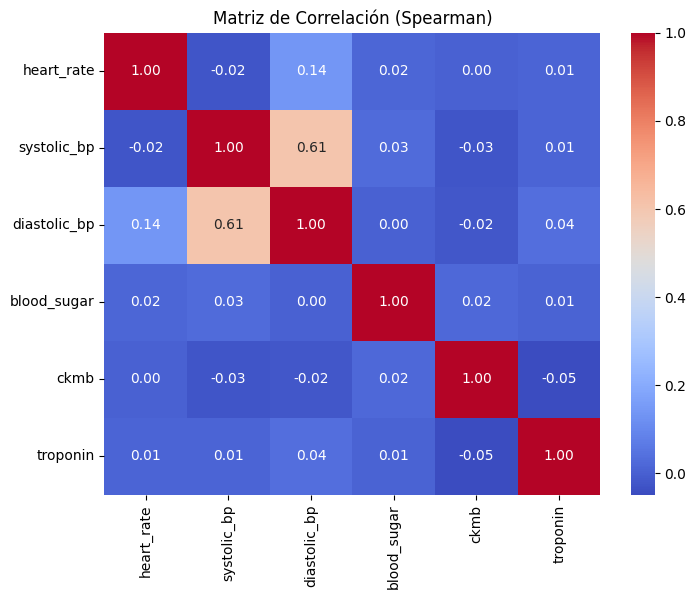

In [19]:
# Matriz de Correlación
corr_matrix = df_data[cols_numericas].corr(method=metodo)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title(f'Matriz de Correlación ({metodo.capitalize()})')
plt.show()

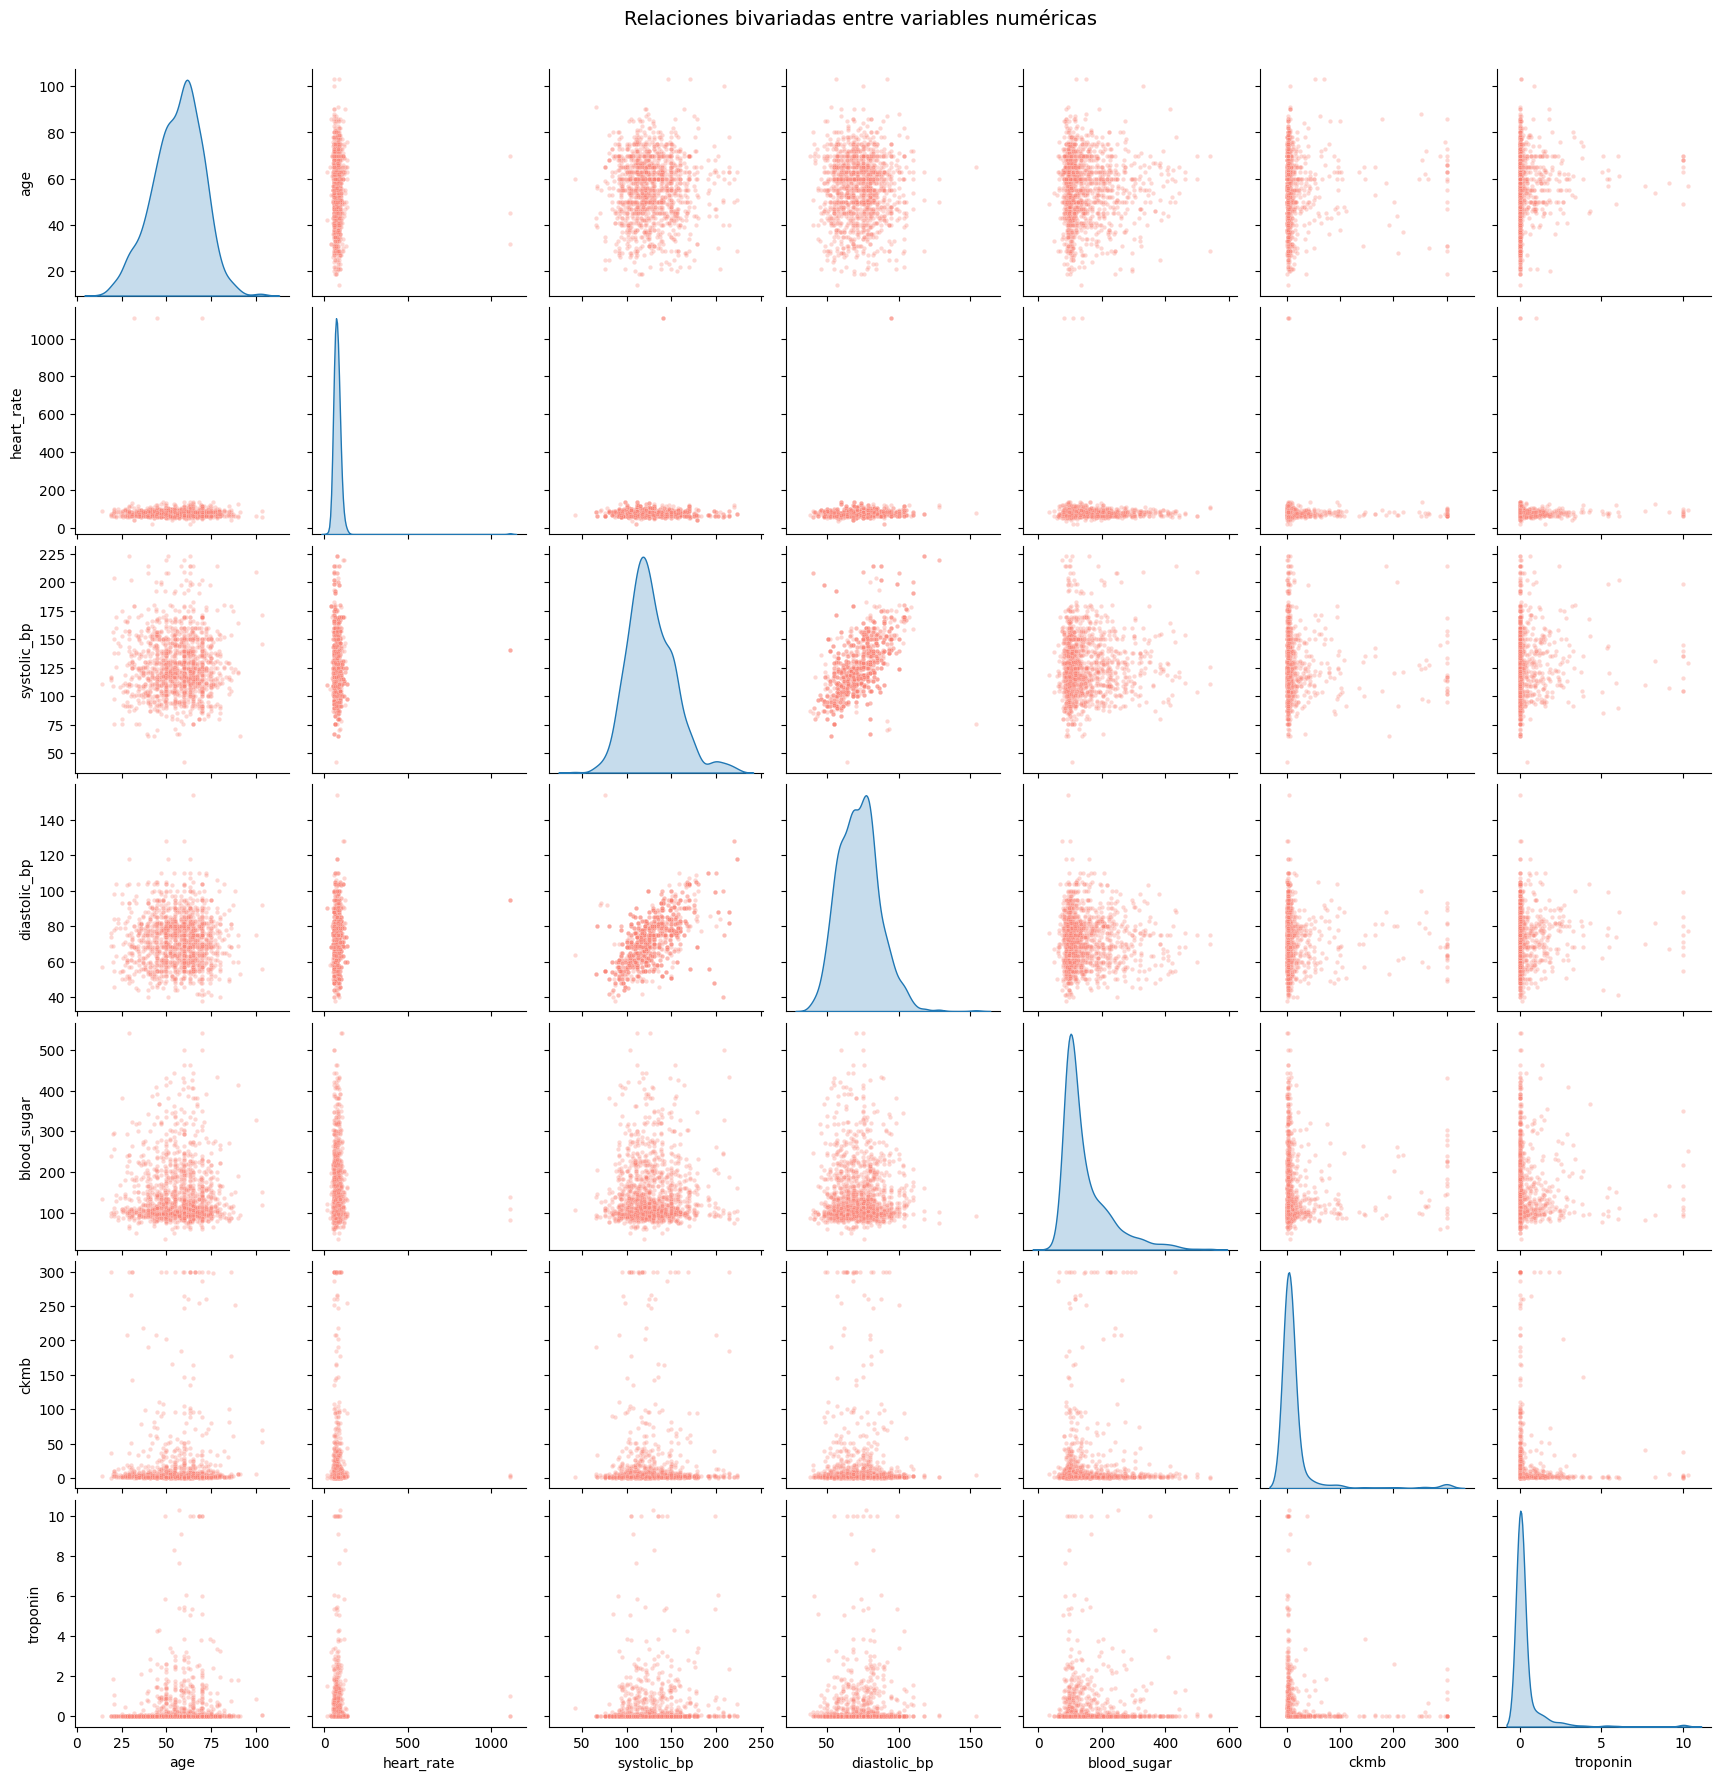

In [20]:
# Gráfico de dispersión pareado
sns.pairplot(
    var_numericas,
    diag_kind="kde",   # histograma o kde en la diagonal
    plot_kws={"alpha":0.3, "s":10, "color": 'salmon'}  # transparencia y tamaño de puntos
)
plt.suptitle("Relaciones bivariadas entre variables numéricas", y=1.02, fontsize=14)
plt.show()

## Almacenamiento de datos

In [21]:
df_data.to_parquet(DATA_DIR / "02_data_ataques_cardiacos_transformados.parquet")